In [ ]:
import matplotlib.pyplot as plt
# import numpy as np

import config, plotting
from dimelo import parse_bam, plot_enrichment_profile

In [7]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"
top_tss_bed_file = config.processed_data_dir / "tss.gm12878_ranked.t2t_chm13v2.quartiles" / "q4.bed"
bam_dir = config.processed_data_dir / "20240628_access_controls"
barcodes = [1, 2]

window_size = 1000
mod_prob_thresh = 0.95
smoothing = 25
n_cores = 10

cg_motifs = [f"{b}CG,1" for b in ("G", "A", "T", "C", "W")]
gc_motifs = [f"GC{b},1" for b in ("G", "A", "T", "C", "H")]
condition_labels = ["control", "gc_access"]
motif_lists = [cg_motifs, gc_motifs]
motif_labels = ["CG", "GC"]
motif_colors = [plotting.default_palette_map["WCG,1"], plotting.default_palette_map["GCH,1"]]

y_lim = (-0.01, 0.5)

In [ ]:
for barcode, condition_label in zip(barcodes, condition_labels):
    bam_file = bam_dir / f"barcode{barcode:02}.sorted.bam"
    for motif_list, motif_label in zip(motif_lists, motif_labels):
        output_id = f"{condition_label}.{motif_label}"
        parse_bam.pileup(
            input_file=bam_file,
            output_name=f"pileup.{output_id}",
            ref_genome=reference_file,
            output_directory=config.processed_data_dir,
            regions=top_tss_bed_file,
            motifs=motif_list,
            thresh=mod_prob_thresh,
            window_size=window_size,
            cores=n_cores,
            override_checks=True
        )

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

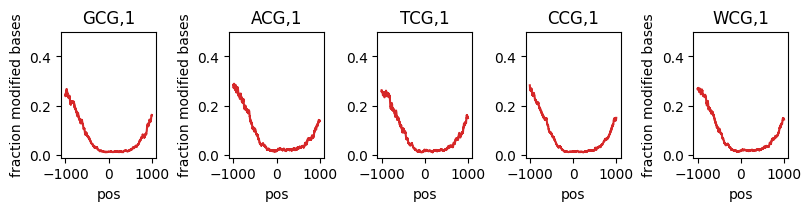

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

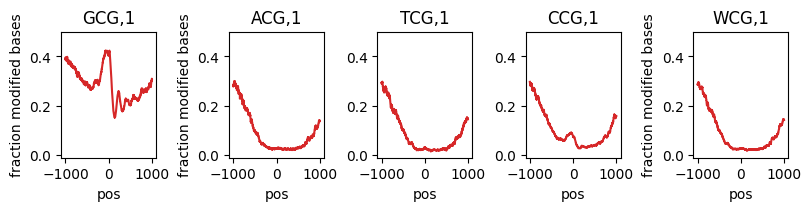

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

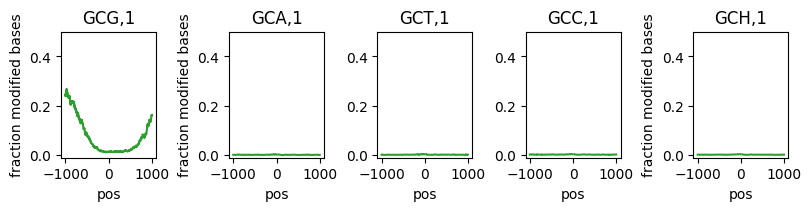

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

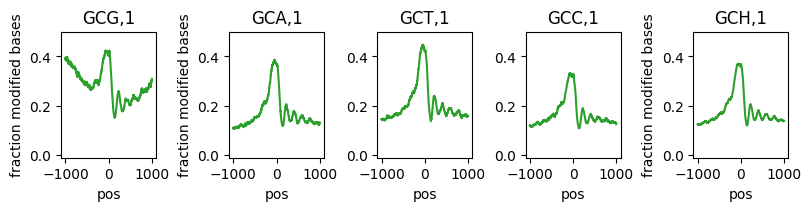

In [8]:
for motif_list, motif_label, color in zip(motif_lists, motif_labels, motif_colors):
    for condition_label in condition_labels:
        fig, axes = plt.subplots(1, 5, layout="constrained", figsize=(8, 2))

        for idx, (ax, motif) in enumerate(zip(axes, motif_list)):
            output_id = f"{condition_label}.{motif_label}"
            plot_enrichment_profile.plot_enrichment_profile(
                mod_file_names=[config.processed_data_dir / f"pileup.{output_id}" / "pileup.sorted.bed.gz"],
                regions_list=[top_tss_bed_file],
                motifs=[motif],
                sample_names=[motif],
                window_size=window_size,
                regions_5to3prime=True,
                smooth_window=smoothing,
                ax=ax,
                palette={motif: color}
            )
            ax.set_title(motif)
            ax.set_ylim(y_lim)
            ax.legend().remove()
            if idx in (2, 3):
                ax.set_ylabel("")

        plt.savefig(config.figure_dir / f"motifs.{condition_label}.{motif_label}.plot_enrichment_profile.svg")
        plt.show()
        plt.close()